# Implied Vol Fit

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the implied vol functionalities in the SDevPy library. In its current state, it uses as example the first model in [[Gurrieri 2010]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1779463).

Named 'TsSvi1' for "Term-Structure SVI 1", this model is essentially the original SVI model by J. Gatheral at each expiry, but where the SVI parameters are parametric functions of time. It is thus a global model for the implied vol surface, calibrated to all options at once. For more details on the properties of this model, see reference above.

In [17]:
import datetime as dt
import numpy as np
from scipy.stats import norm
import pandas as pd
from platform import python_version
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.analytics import black
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.market.yieldcurve import get_yieldcurve
from sdevpy.market.eqforward import get_forward_curves
from sdevpy.volatility.impliedvol.models.tssvi1 import TsSvi1
from sdevpy.volatility.impliedvol.models.tssvi2 import TsSvi2
from sdevpy.volatility.impliedvol.models.logmix import LogMix
from sdevpy.volatility.impliedvol.impliedvol_calib import TsIvCalibrator
from sdevpy.volatility.localvol.dupire import calib_lv_dupire
from sdevpy.volatility.localvol.localvol import MatrixLocalVol
from sdevpy.utilities import dates as dts
from sdevpy.utilities import timegrids
from sdevpy.maths.metrics import rmse
from sdevpy.utilities.algos import upper_bound


print("Python version: " + python_version())
print("NumPy version: " + np.__version__)
print("SDevPy version: " + sd.__version__)

Python version: 3.14.0
NumPy version: 2.3.5
SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [2]:
name = "ABC"
valdate = dt.datetime(2025, 12, 15)

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]

# Retrieve option data
file = vsurf.data_file(name, valdate)
option_data = vsurf.eqvolsurfacedata_from_file(file)
mkt_data = {'option_data': option_data, 'forward_curve': fwd_curve}
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = option_data.expiries
fwds = fwd_curve.value(expiries)
mkt_strikes = option_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
mkt_vols = option_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(mkt_strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(mkt_strikes[i])}/{len(mkt_vols[i])}")

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5


In [78]:
# Initialize model
# iv_surface = LogMix(2)
iv_surface = TsSvi1()

# Calibrate model
calibrator = TsIvCalibrator(iv_surface, {'optimizer': 'SLSQP', 'tol': 1e-6})
calibrator.calibrate(mkt_data)

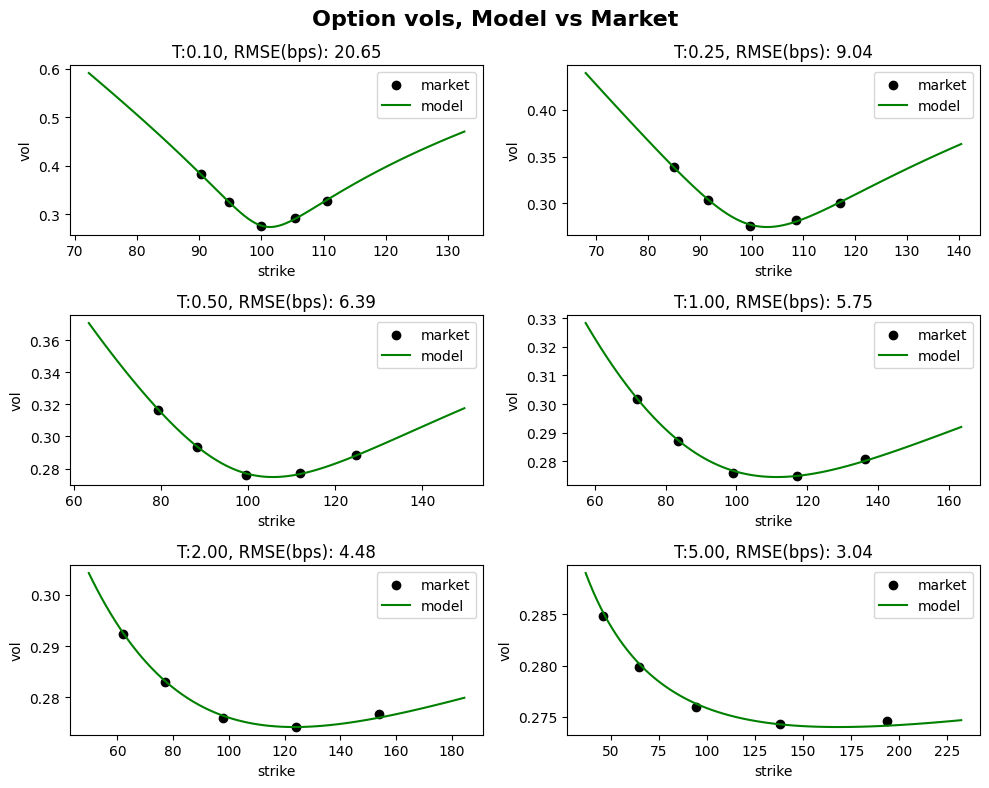

In [79]:
# Estimate model on points and calculate RMSE, plot comparison
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = timegrids.model_time(valdate, expiries[exp_idx])
        fwd = fwds[exp_idx]
        exp_strikes = mkt_strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        m_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        m_vols = iv_surface.black_volatility(expiry, m_strikes, fwd)
        ax.scatter(exp_strikes, mkt_vols[exp_idx], label="market", color='black')
        ax.plot(m_strikes, m_vols, label="model", color='green')
        model_vols = iv_surface.black_volatility(expiry, exp_strikes, fwd)
        vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Local Vol Calibration (Dupire)
Now we use the implied volatility surface calibrated to market data in the previous section to derive the corresponding local volatility using the Dupire method.

In [81]:
# Granularity
points_per_year = 25
n_strikes = 100

# Retrieve calibration horizon
tmax = timegrids.model_time(valdate, expiries.max())

# Launch Dupire calibration
lv_calib = calib_lv_dupire(iv_surface, points_per_year=25, n_strikes=n_strikes,
                           tmax=tmax)
lv_t = lv_calib['t_grid']
lv_moneyness = lv_calib['moneyness']
lv_matrix = lv_calib['lv']
lv_obj = MatrixLocalVol(lv_t, np.log(lv_moneyness), lv_matrix)
lv_map = {name: lv_obj}

In [82]:
# Define 6 expiries to inspect the model (do not have to be the market's)
plot_tenors = ['1m', '3m', '6m', '9m', '1y', '2y']
plot_dates = [dts.advance(valdate, tenor) for tenor in plot_tenors]
plot_t = timegrids.model_time(valdate, plot_dates)

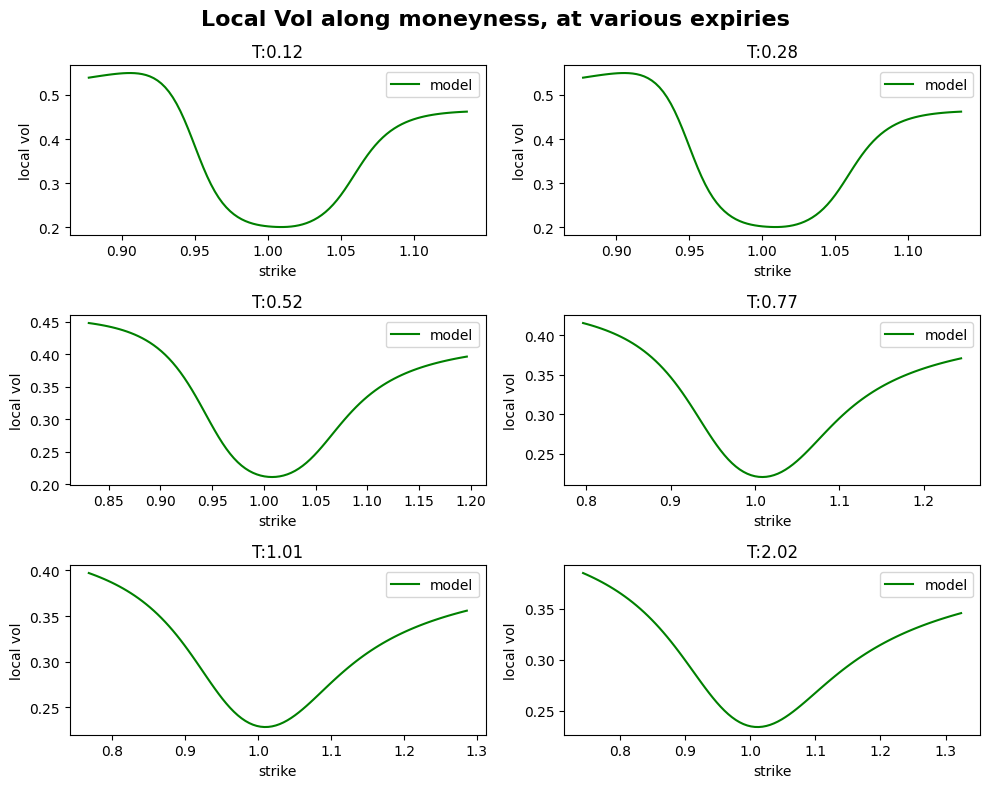

In [83]:
# View the LV along the strike at several expiries
t_idx = [upper_bound(lv_t, tp) for tp in plot_t]
plot_lv_t = lv_t[t_idx]

n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_lv_t[exp_idx]
        ax.plot(lv_moneyness[exp_idx], lv_matrix[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along moneyness, at various expiries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

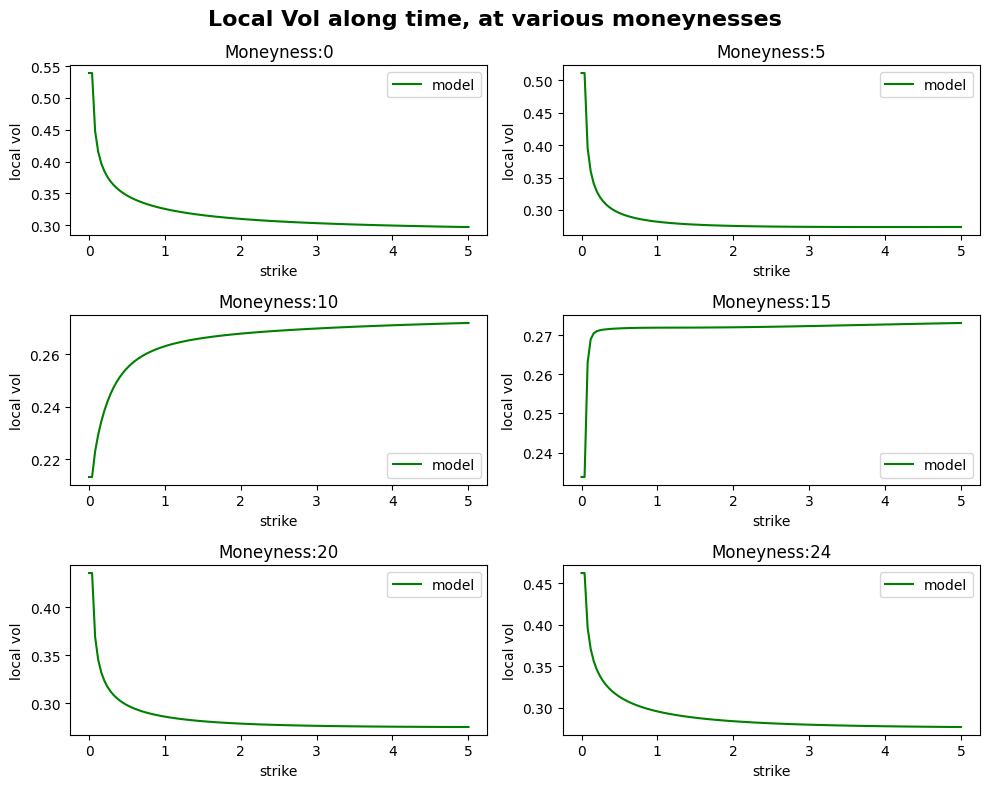

In [61]:
# View LV along the expiry at several moneynesses
m_idx = [0, 5, 10, 15, 20, 24]
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        k_idx = n_cols * i + j
        k_idx = m_idx[k_idx]
        lv_ = [lv_matrix[tidx][k_idx] for tidx in range(len(lv_t))]
        ax.plot(lv_t, lv_, label="model", color='green')
        ax.set_title(f"Moneyness:{k_idx}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along time, at various moneynesses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Compare MC prices to IV model

In [84]:
# At the 6 expiries chosen to look at the model, we calculate a range of
# strikes within certain reasonable percentiles of the distribution.
n_strikes = 10
lw_p = 0.05
up_p = 1.0 - lw_p
percentiles = np.linspace(lw_p, up_p, n_strikes)
n_quantiles = norm.ppf(percentiles)
plot_fwds, plot_strikes, plot_mod_prices, plot_mod_ivs = [], [], [], []
for date, time in zip(plot_dates, plot_t, strict=True):
    fwd = fwd_curve.value(date)
    atm = iv_surface.black_volatility(time, fwd, fwd)
    stdev = atm * np.sqrt(time)
    strikes = fwd * np.exp(-0.5 * stdev * stdev + stdev * n_quantiles)
    plot_fwds.append(fwd)
    plot_strikes.append(strikes)
    plot_mod_prices.append(iv_surface.forward_price(time, strikes, True, fwd))
    plot_mod_ivs.append(iv_surface.black_volatility(time, strikes, fwd))

In [86]:
from sdevpy.utilities import book as bk
from sdevpy.montecarlo.payoffs.vanillas import make_vanilla_option
from sdevpy.montecarlo.payoffs import cashflows as cfl
from sdevpy.montecarlo.payoffs.basic import Trade, Instrument
from sdevpy.montecarlo.mcpricer import price_book

n_paths = 20000
n_steps = 250

# Create portfolio
option_type = 'Call'
trades = []
for exp_idx, expiry in enumerate(plot_dates):
    exp_strikes = plot_strikes[exp_idx]
    for strike in exp_strikes:
        index = make_vanilla_option(name, strike, option_type, expiry)
        cf = cfl.Cashflow(index, expiry)
        trades.append(Trade(Instrument(cashflow_legs=[[cf]])))

# Create book
book = bk.Book()
book.add_trades(trades)

# Price book
mc_price = price_book(valdate, book, constr_type='brownianbridge', rng_type='sobol',
                      n_paths=n_paths, n_timesteps=n_steps, lv_map=lv_map)

# Gather results per expiry
disc_curve = get_yieldcurve(book.csa_curve_id, valdate)
mc_prices, mc_ivs = [], []
count = 0
for i in range(len(plot_dates)):
    expiry = plot_t[i]
    fwd = plot_fwds[i]
    # Calculate discount factor to forward MC prices
    disc = disc_curve.discount(plot_dates[i])

    # Collect prices and calculate MC IVs
    exp_mc_prices, exp_mc_ivs = [], []
    exp_strikes = plot_strikes[i]
    for j in range(len(exp_strikes)):
        fwd_price = mc_price['pv'][count] / disc
        strike = exp_strikes[j]
        try:
            iv = black.implied_vol(expiry, strike, True, fwd, fwd_price)
        except Exception:
            iv = np.nan
        exp_mc_prices.append(fwd_price)
        exp_mc_ivs.append(iv)
        count += 1

    mc_prices.append(exp_mc_prices)
    mc_ivs.append(exp_mc_ivs)

print(f"MC prices: {mc_prices}")
print(f"MC IVs: {mc_ivs}")

{'ABC': <sdevpy.volatility.localvol.localvol.MatrixLocalVol object at 0x000002359E8F27A0>}
Runtime(Generate spot paths): 1.7s
Runtime(Interpolate to event grid): 0.0s
Runtime(Payoff calculation): 0.1s
MC prices: [[np.float64(12.935151823920503), np.float64(8.867327763571051), np.float64(6.515037401958658), np.float64(4.7601698388416), np.float64(3.374989980037707), np.float64(2.2975468644797084), np.float64(1.4917261696219912), np.float64(0.9122730207945606), np.float64(0.5002325185864803), np.float64(0.1878581262380124)], [np.float64(21.399129253705073), np.float64(15.060197360319318), np.float64(11.357848786066283), np.float64(8.587511937727083), np.float64(6.3563660846695), np.float64(4.548157955965637), np.float64(3.1026965183219772), np.float64(1.968643577477408), np.float64(1.0967214764722522), np.float64(0.3951274316819611)], [np.float64(29.50409376846285), np.float64(21.252715531425363), np.float64(16.346740292622655), np.float64(12.627550800070418), np.float64(9.59542027447457

In [87]:
for i in range(len(plot_dates)):
    mc_iv = mc_ivs[i]
    mod_iv = plot_mod_ivs[i]
    for mc, mod in zip(mc_iv, mod_iv, strict=True):
        print(f"Mod/MC: {mod}/{mc}")

Mod/MC: 0.4391948262185248/0.3121267448816849
Mod/MC: 0.37772882210265096/0.2783688412507257
Mod/MC: 0.3384784666831254/0.256979588182665
Mod/MC: 0.3075620217383377/0.24102991660305326
Mod/MC: 0.284575699265988/0.23016317763704058
Mod/MC: 0.27402021740654325/0.22514735093265015
Mod/MC: 0.2790222018318484/0.2260326721083638
Mod/MC: 0.29660663923772107/0.23297149132326161
Mod/MC: 0.32454774106998896/0.24680682963673234
Mod/MC: 0.37238978245872656/0.2731294421529471
Mod/MC: 0.3715005490301498/0.3080479166093908
Mod/MC: 0.33156342980088765/0.28318470884224917
Mod/MC: 0.3083892303872762/0.26849621529860096
Mod/MC: 0.2919855214531676/0.2583045929682275
Mod/MC: 0.28084499028649834/0.2508329257844007
Mod/MC: 0.27515818648954976/0.24697201756448514
Mod/MC: 0.27537599689916425/0.2468640029307686
Mod/MC: 0.2817583565667201/0.25075165145185524
Mod/MC: 0.29529329862507253/0.26014385144206714
Mod/MC: 0.32338130951302085/0.2788627367988593
Mod/MC: 0.34037692433216454/0.30124519600574406
Mod/MC: 0.312

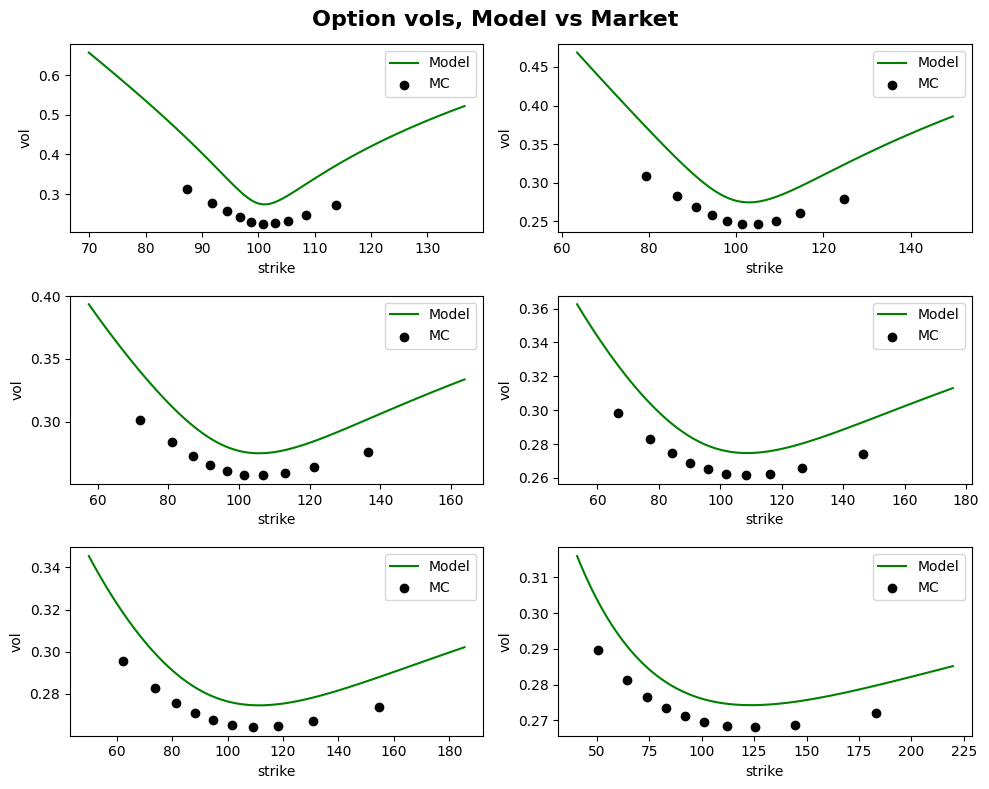

In [88]:
# Plot
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_dates[exp_idx]
        t = plot_t[exp_idx]
        fwd = plot_fwds[exp_idx]
        exp_strikes = plot_strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        mod_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        mod_vols = iv_surface.black_volatility(t, mod_strikes, fwd)
        ax.plot(mod_strikes, mod_vols, label="Model", color='green')
        ax.scatter(exp_strikes, mc_ivs[exp_idx], label="MC", color='black')
        # vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        # ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Compare against PDE prices